# LC Notebook Diff E2E Test - Basic Functionality on JupyterLab

- Test that LC Notebook Diff extension works properly
- Verify that Diff widget is accessible in left panel
- Verify that file selection and diff display work correctly

In [15]:
jupyterlab_url = "http://localhost:8888/lab?token=test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 10000
default_delay = 200
browser_type = "chromium"
jupyter_work_dir = '../artifacts/jupyter-work'

In [16]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxt1s7zzh'

In [17]:
import re
import asyncio
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

import scripts.jupyterlab as jupyterlab
importlib.reload(jupyterlab)

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, delay=default_delay, browser_type=browser_type)

('20251114-181329',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmptl8_niiv')

## Open JupyterLab and wait for it to load

Start epoch: 1763111610.2302132 seconds
JupyterLab loaded successfully


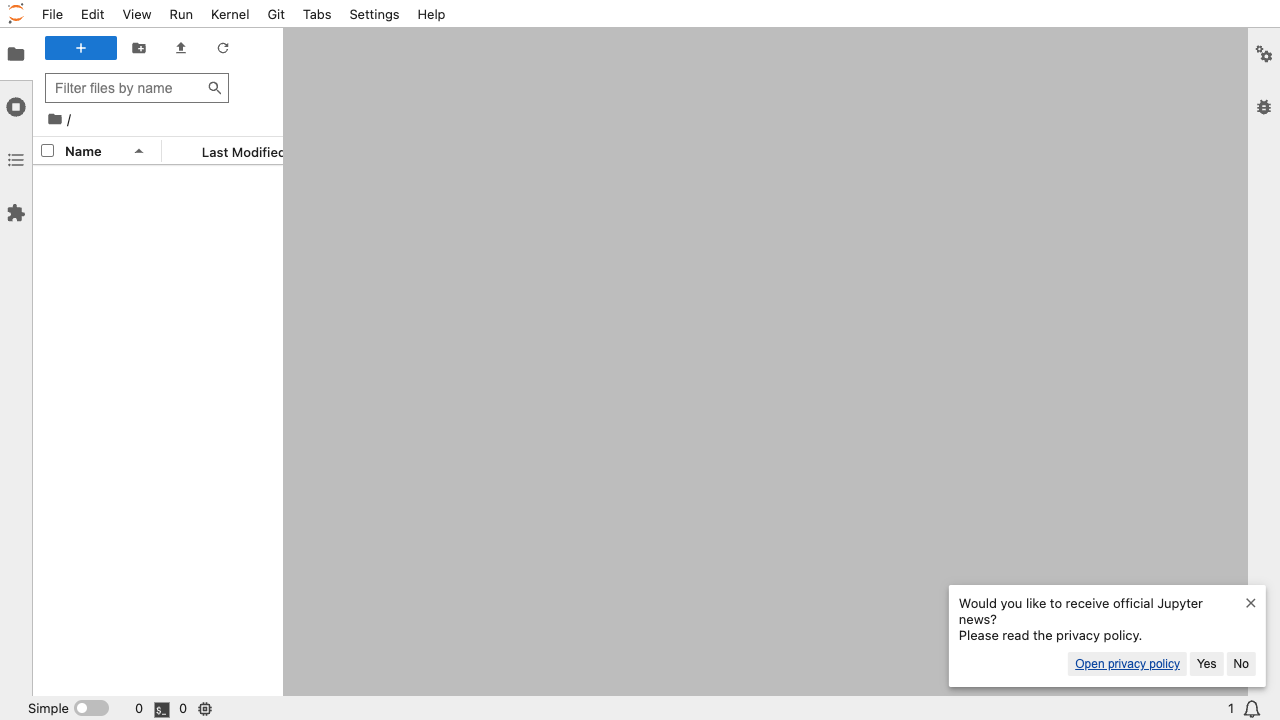

In [18]:
lab_page = None

async def _step(page):
    await page.goto(jupyterlab_url)

    # Wait for JupyterLab to load
    await expect(page.locator('#jp-main-dock-panel')).to_be_visible(timeout=transition_timeout)

    # Ensure file browser is visible
    # If File Browser tab is not selected, click it
    filebrowser_tab = page.locator('[data-id="filebrowser"]')
    if await filebrowser_tab.get_attribute('aria-selected') == 'false':
        await filebrowser_tab.click()
    
    # Wait for file browser to be visible
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

    global lab_page
    lab_page = page
    
    print("JupyterLab loaded successfully")

await run_pw(_step)

## Click on Diff icon in left sidebar to open Diff widget

Start epoch: 1763111613.126871 seconds


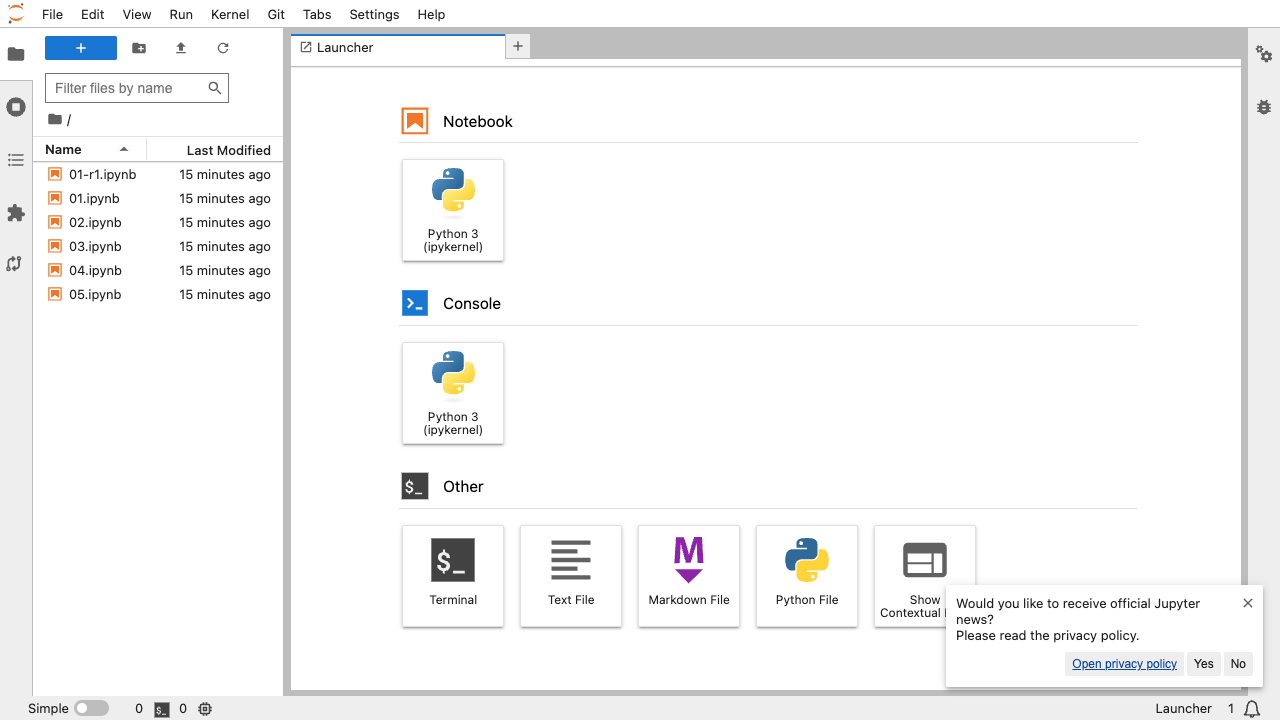

In [19]:
async def _step(page):
    # Close any previously opened notebook tabs
    notebook_names = ['01.ipynb', '01-r1.ipynb', '02.ipynb', '03.ipynb', '04.ipynb', '05.ipynb']
    for notebook_name in notebook_names:
        notebook_tab = page.locator(f'//*[contains(@class, "lm-TabBar-tabLabel") and text()="{notebook_name}"]')
        if await notebook_tab.is_visible():
            # Click on the tab to make it active
            await notebook_tab.click()
            await expect(notebook_tab.locator('..')).to_have_class(re.compile(r'lm-mod-current'))
            
            # Click the close icon
            close_icon = notebook_tab.locator('..').locator('.lm-TabBar-tabCloseIcon')
            await close_icon.click()
            
            # Check if Discard button appears and click it
            discard_button = page.locator('//*[@class="jp-Dialog-buttonLabel" and text()="Discard"]')
            if await discard_button.is_visible():
                await discard_button.click()
                print(f"Clicked Discard button for {notebook_name}")
            
            # Wait for the tab to disappear
            await expect(notebook_tab).not_to_be_visible(timeout=transition_timeout)
            print(f"Closed previously opened {notebook_name}")

await run_pw(_step)

Start epoch: 1763111613.4550169 seconds
Clicked on Diff tab in left sidebar
Found 3 file input fields
Show Diff button is visible


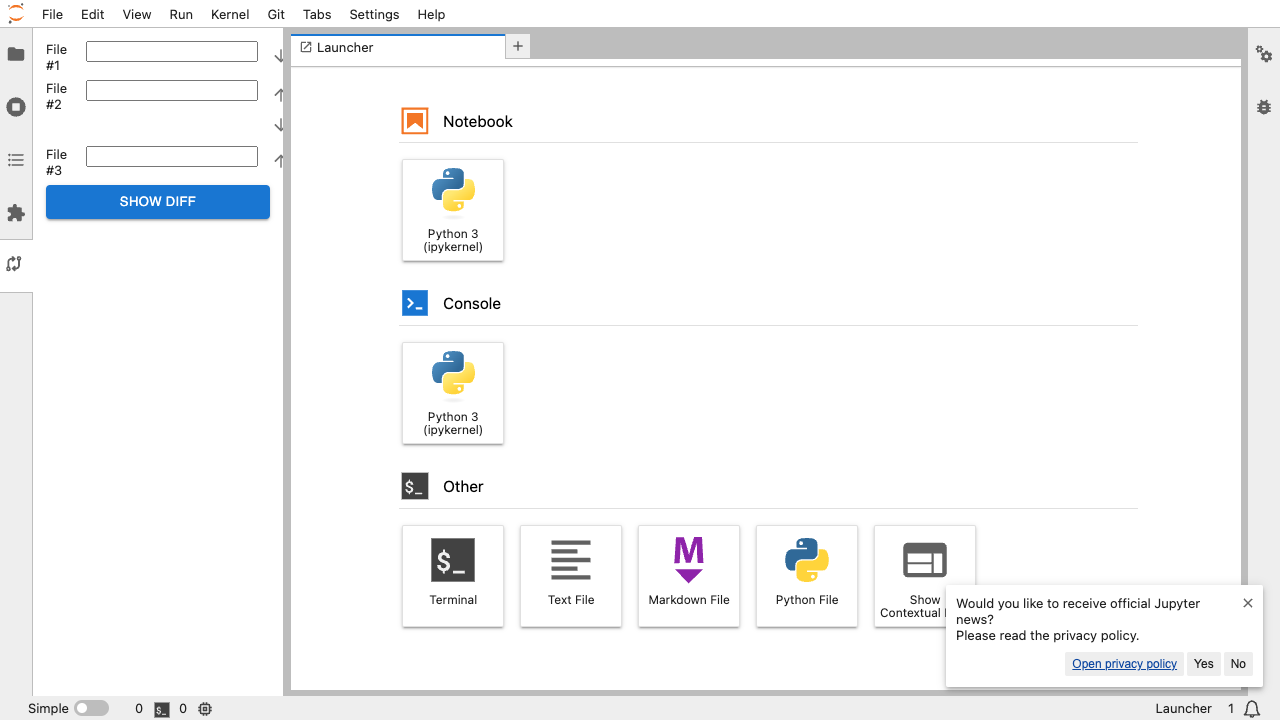

In [20]:
async def _step(page):
    # Click on Diff tab in left sidebar
    diff_tab = page.locator('[data-id="lc_notebook_diff::main"]')
    await expect(diff_tab).to_be_visible(timeout=transition_timeout)
    await diff_tab.click()
    
    print("Clicked on Diff tab in left sidebar")
    
    # Verify that file input fields are visible
    file_inputs = page.locator('.jupyter-notebook-diff-files input')
    await expect(file_inputs).to_have_count(3, timeout=transition_timeout)
    
    print("Found 3 file input fields")
    
    # Verify that Show Diff button is visible
    show_diff_button = page.locator('button.jupyter-notebook-diff-show-diff')
    await expect(show_diff_button).to_be_visible(timeout=transition_timeout)
    
    print("Show Diff button is visible")

await run_pw(_step)

## Enter notebook paths and click Show Diff

Start epoch: 1763111613.803772 seconds
Entered 01.ipynb in File #1
Entered 01-r1.ipynb in File #2
Clicked Show Diff button


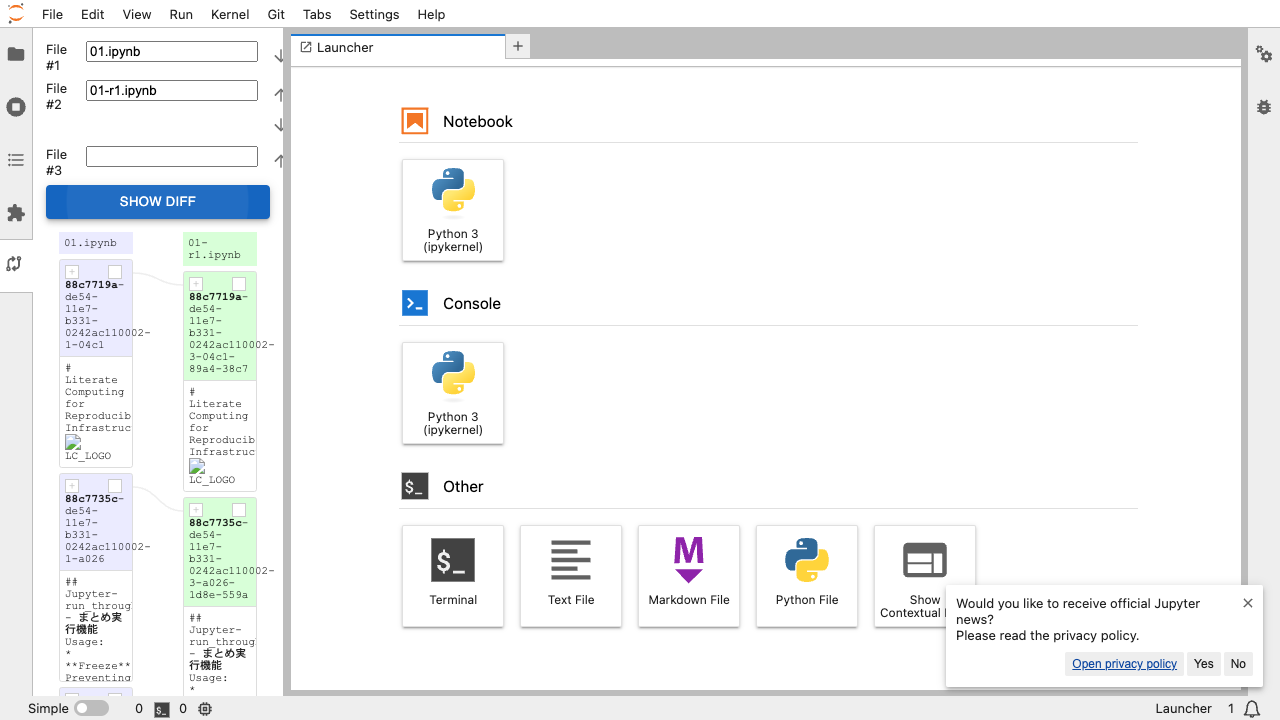

In [21]:
async def _step(page):
    # Enter paths for two notebooks to compare
    file_inputs = page.locator('.jupyter-notebook-diff-files input')
    
    # Fill first input with 01.ipynb
    first_input = file_inputs.nth(0)
    await first_input.fill('01.ipynb')
    print("Entered 01.ipynb in File #1")
    
    # Fill second input with 01-r1.ipynb
    second_input = file_inputs.nth(1)
    await second_input.fill('01-r1.ipynb')
    print("Entered 01-r1.ipynb in File #2")
    
    # Click Show Diff button
    show_diff_button = page.locator('button.jupyter-notebook-diff-show-diff')
    await show_diff_button.click()
    
    print("Clicked Show Diff button")

await run_pw(_step)

## Verify that diff content is displayed

Start epoch: 1763111614.360279 seconds
Diff widget is visible
Diff wrapper is visible
Diff view is displaying 39 cells correctly


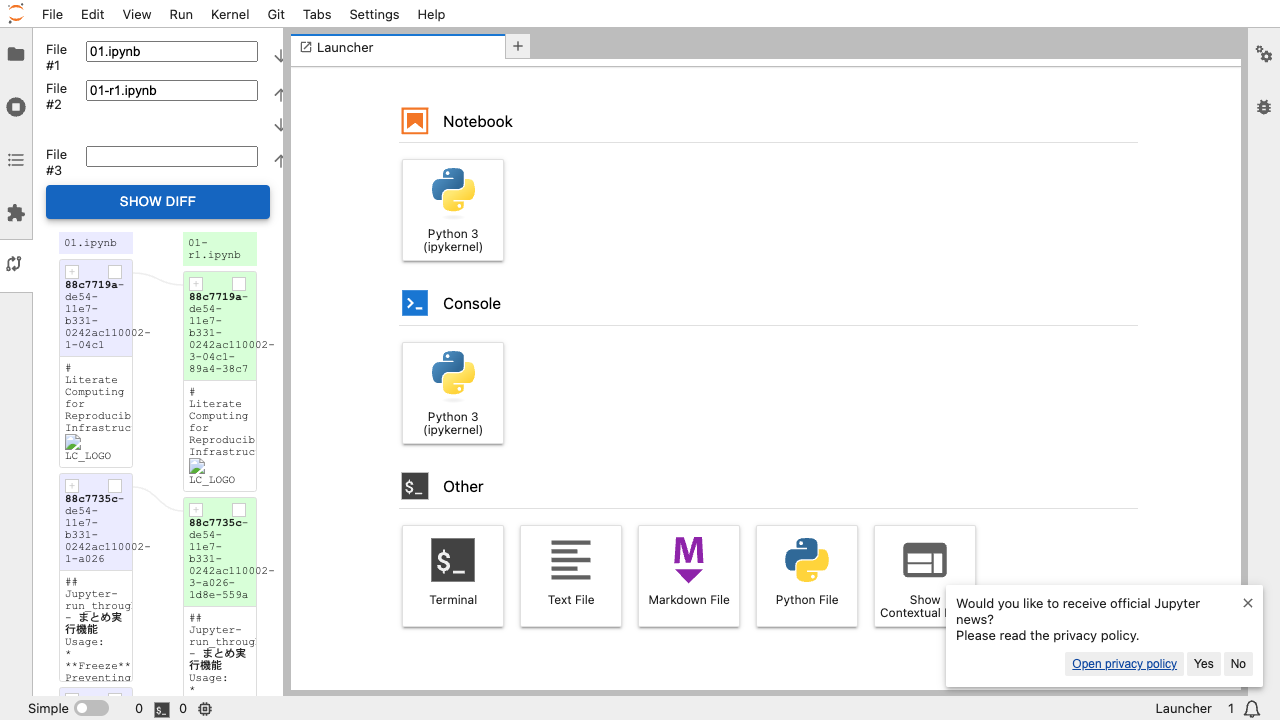

In [22]:
async def _step(page):
    # Verify that diff widget is visible
    diff_widget = page.locator('.jupyter-notebook-diff')
    await expect(diff_widget).to_be_visible(timeout=transition_timeout)
    
    print("Diff widget is visible")
    
    # Verify that wrapper element exists (from DiffView.ts:308)
    wrapper = page.locator('.jupyter-notebook-diff .wrapper')
    await expect(wrapper).to_be_visible(timeout=transition_timeout)
    
    print("Diff wrapper is visible")
    
    # Verify that cell elements are rendered
    # 01.ipynb has 19 cells, 01-r1.ipynb has 20 cells, so total 39 cells
    cells = page.locator('.jupyter-notebook-diff .cell')
    await expect(cells).to_have_count(39, timeout=transition_timeout)
    
    print("Diff view is displaying 39 cells correctly")

await run_pw(_step)

## Clean up

In [23]:
await finish_pw_context()

Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxt1s7zzh/video-1.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxt1s7zzh/har.zip
Console log: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpxt1s7zzh/console.log


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-cloud/Jupyter-LC_notebook_diff/ui-tests/e2e-notebook/notebooks/scripts/playwright.py", line 254, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmptl8_niiv/videos/d88ae185da01ea487d027b16bfe83acb.webm'


In [24]:
!rm -fr {work_dir}